# Rap Corpus - Exploratory Analysis
## Descriptive Statistics and Initial Exploration

This notebook provides an initial analysis of the rap corpus with descriptive statistics, visualizations and insights into the composition of the corpus.

## 1. Import Required Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import string
import os
import re
from pathlib import Path
from wordcloud import WordCloud

# Display configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Setup - Create Output Directories

In [31]:
notebook_prefix = 'R00'

# Create output directories if they don't exist
images_dir = Path('images')
export_dir = Path('export')

images_dir.mkdir(exist_ok=True)
export_dir.mkdir(exist_ok=True)

print(f"✓ 'images' folder created: {images_dir.resolve()}")
print(f"✓ 'export' folder created: {export_dir.resolve()}")

✓ 'images' folder created: /home/cbenavent/test/Rap/images
✓ 'export' folder created: /home/cbenavent/test/Rap/export


## 2. Load the Corpus File

In [32]:
# Corpus file path
corpus_path = Path('.') / 'corpus.csv'

# Load corpus with error handling
try:
    df = pd.read_csv(corpus_path, encoding='utf-8', on_bad_lines='skip')
    print(f"✓ Corpus loaded successfully from: {corpus_path}")
except UnicodeDecodeError:
    df = pd.read_csv(corpus_path, encoding='latin-1', on_bad_lines='skip')
    print(f"✓ Corpus loaded with latin-1 encoding from: {corpus_path}")

print(f"\nCorpus shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print("\nFirst rows of corpus:")
df.head()

✓ Corpus loaded successfully from: corpus.csv

Corpus shape: (85023, 10)

Columns: ['doc_id', 'artist', 'title', 'year', 'album', 'lyrics', 'n_words', 'pageviews', 'contributors', 'url']

First rows of corpus:


,doc_id,artist,title,year,album,lyrics,n_words,pageviews,contributors,url
0,1,Dry,94310,2012.0,Tôt ou tard,"[Paroles de ""94310"" ft. Madj, Larso & Stokas]\...",748,0,8,https://genius.com/Dry-94310-lyrics
1,2,Mafia K’1 Fry,Au bon vieux temps,2007.0,Jusqu’à la mort,"\nEt je les entends tous les Zoulous, ils parl...",958,7514,8,https://genius.com/Mafia-k1-fry-au-bon-vieux-t...
2,3,DJ Hamida,Attrape-Moi Si Tu Peux,NaN,Mix Party 2015,[Refrain : Charly Bell]\nOui je sais qu’t’as e...,367,0,4,https://genius.com/Dj-hamida-attrape-moi-si-tu...
3,4,Kery James,94 c’est le Barça Remix,NaN,NaN,"\nC'est pour les rudeboys, c'est pour les cail...",535,0,7,https://genius.com/Kery-james-94-cest-le-barca...
4,5,Dry,14 ans déjà,2013.0,Maintenant ou jamais,"[Paroles de ""14 ans déjà""]\n\n\nTu sais, j'cro...",653,5037,8,https://genius.com/Dry-14-ans-deja-lyrics


## 2.5 Data Quality Diagnostic & Cleaning

Identify and fix data quality issues before analysis

In [41]:
# 3. Check for extremely long lyrics
print('\n--- TEXT LENGTH ANALYSIS ---')
df['char_count_raw'] = df['lyrics'].fillna('').astype(str).str.len()
df['word_count_raw'] = df['lyrics'].fillna('').astype(str).str.split().str.len()

extremely_long_chars = (df['char_count_raw'] > 100000).sum()
extremely_long_words = (df['word_count_raw'] > 10000).sum()

print(f'  Extremely long (>100k chars): {extremely_long_chars} documents')
if extremely_long_chars > 0:
    print(f'  Examples: {df[df["char_count_raw"] > 100000][["doc_id", "artist", "title", "char_count_raw"]].head()}')

print(f'  Extremely long (>10k words): {extremely_long_words} documents')
if extremely_long_words > 0:
    print(f'  Examples: {df[df["word_count_raw"] > 10000][["doc_id", "artist", "title", "word_count_raw"]].head()}')

# Create flag for documents to exclude
df['is_too_long'] = df['word_count_raw'] > 10000

print(f'\n✓ Diagnostic complete')


--- TEXT LENGTH ANALYSIS ---
  Extremely long (>100k chars): 1 documents
  Examples:        doc_id artist         title  char_count_raw
30969   30970   Urde  Si J’le Veux          108422
  Extremely long (>10k words): 1 documents
  Examples:        doc_id           artist            title  word_count_raw
48580   48581  Artistes divers  Morts pour rien           11302

✓ Diagnostic complete


## 3. Basic Corpus Information

## 2.6 Create Clean Corpus Dataset

Export filtered corpus without spam/corrupted content for downstream analyses

In [ ]:
# === CREATE CLEAN CORPUS & EXPORT CSV ===
print('\n' + '=' * 70)
print('CREATING CLEAN CORPUS DATASET')
print('=' * 70)

# Filter out spam/corrupted documents AND documents with >10k words
corpus_clean = df[~df['is_spam_lyrics'] & ~df['is_too_long']].copy()

print(f'\n--- Corpus Comparison ---')
print(f'Original corpus:     {len(df):>8,} documents')
print(f'Spam/corrupted:      {df["is_spam_lyrics"].sum():>8,} documents')
print(f'Too long (>10k words): {df["is_too_long"].sum():>8,} documents')
print(f'Total removed:       {(df["is_spam_lyrics"] | df["is_too_long"]).sum():>8,} documents')
print(f'Clean corpus:        {len(corpus_clean):>8,} documents')
print(f'Retention rate:      {len(corpus_clean)/len(df)*100:>7.1f}%')

# Drop temporary columns before export
corpus_clean_export = corpus_clean.drop(columns=['is_spam_lyrics', 'char_count_raw', 'word_count_raw', 'is_too_long'])

# Export to CSV
corpus_clean_path = Path('.') / 'corpus_clean.csv'
corpus_clean_export.to_csv(corpus_clean_path, index=False, encoding='utf-8')

print(f'\n✓ Clean corpus exported: {corpus_clean_path}')
print(f'  File size: {corpus_clean_path.stat().st_size / (1024**2):.2f} MB')
print(f'  Columns: {corpus_clean_export.columns.tolist()}')

# Show sample
print(f'\nSample records from clean corpus:')
print(corpus_clean_export[['doc_id', 'artist', 'title', 'year']].head(10).to_string(index=False))

# Statistics comparison - calculate char_count on the fly
print(f'\n--- Text Length Statistics (Clean vs Original) ---')
print(f'\nCharacter count:')
char_count_orig = df['lyrics'].fillna('').astype(str).str.len()
char_count_clean = corpus_clean['lyrics'].fillna('').astype(str).str.len()
print(f'  Mean: {char_count_clean.mean():>8.0f} (original: {char_count_orig.mean():>8.0f})')
print(f'  Median: {char_count_clean.median():>6.0f} (original: {char_count_orig.median():>6.0f})')
print(f'  Max: {char_count_clean.max():>8.0f} (original: {char_count_orig.max():>8.0f})')

# === REPLACE df WITH CLEAN CORPUS FOR ALL SUBSEQUENT ANALYSES ===
df = corpus_clean_export.copy()
print(f'\n✓ Clean corpus ready for downstream analyses')
print(f'✓ All subsequent analyses will use the cleaned dataset ({len(df):,} documents)')


CREATING CLEAN CORPUS DATASET

--- Corpus Comparison ---
Original corpus:       85,023 documents
Spam/corrupted:            10 documents
Too long (>10k words):        1 documents
Total removed:             11 documents
Clean corpus:          85,012 documents
Retention rate:        100.0%

✓ Clean corpus exported: corpus_clean.csv
  File size: 221.10 MB
  Columns: ['doc_id', 'artist', 'title', 'year', 'album', 'lyrics', 'n_words', 'pageviews', 'contributors', 'url', 'char_count', 'word_count']

Sample records from clean corpus:
 doc_id          artist                   title   year
      1             Dry                   94310 2012.0
      2   Mafia K’1 Fry      Au bon vieux temps 2007.0
      3       DJ Hamida  Attrape-Moi Si Tu Peux    NaN
      4      Kery James 94 c’est le Barça Remix    NaN
      5             Dry             14 ans déjà 2013.0
      6           Lynda              A ma place 2014.0
      7             Dry             Atlantis #2 2020.0
      8 Sexion d’Assaut   

In [43]:
print("=" * 60)
print("BASIC CORPUS INFORMATION")
print("=" * 60)

# Global metadata
print(f"\nTotal number of documents: {len(df):,}")
print(f"Number of columns: {df.shape[1]}")
print(f"Memory size: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

# Statistics by column
print("\n" + "=" * 60)
print("STATISTICS BY COLUMN")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("DATA OVERVIEW")
print("=" * 60)
print(df.describe(include='all').T)

BASIC CORPUS INFORMATION

Total number of documents: 85,023
Number of columns: 16
Memory size: 227.41 MB

STATISTICS BY COLUMN
<class 'pandas.DataFrame'>
RangeIndex: 85023 entries, 0 to 85022
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   doc_id          85023 non-null  int64  
 1   artist          85023 non-null  str    
 2   title           85023 non-null  str    
 3   year            75388 non-null  float64
 4   album           69880 non-null  str    
 5   lyrics          84852 non-null  str    
 6   n_words         85023 non-null  int64  
 7   pageviews       85023 non-null  int64  
 8   contributors    85023 non-null  int64  
 9   url             85023 non-null  str    
 10  is_spam_lyrics  85023 non-null  bool   
 11  char_count_raw  85023 non-null  int64  
 12  char_count      85023 non-null  int64  
 13  word_count      85023 non-null  int64  
 14  word_count_raw  85023 non-null  int64  
 15  is_to

## 4. Text Length Statistics

In [47]:
# Define the text column to analyze
text_col = 'lyrics'

# Verify the column exists
if text_col not in df.columns:
    print(f"Error: Column '{text_col}' not found in dataset")
    print(f"Available columns: {df.columns.tolist()}")
else:
    print(f"✓ Analysis will focus on the '{text_col}' column")

✓ Analysis will focus on the 'lyrics' column



TEXT LENGTH STATISTICS - LYRICS ANALYSIS

Characters per document:
  Minimum: 0 characters
  Maximum: 108,422 characters
  Mean: 2,538 characters
  Median: 2,409 characters
  Std Dev: 1,486

Words per document:
  Minimum: 0 words
  Maximum: 11,302 words
  Mean: 456 words
  Median: 433 words
  Std Dev: 257

✓ Figure saved: images/01_text_length.png


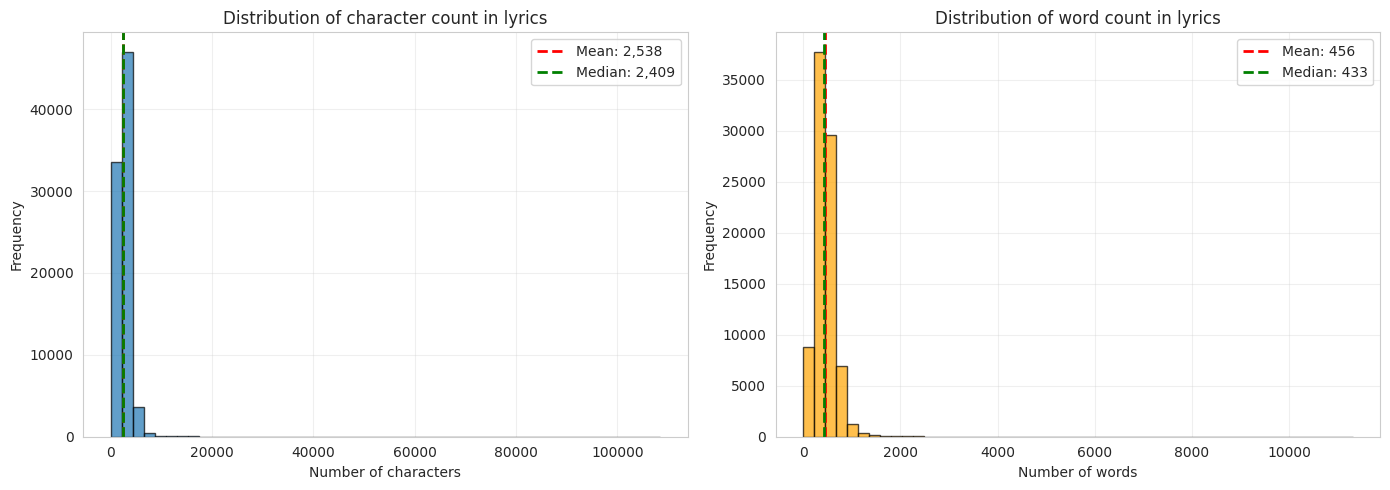

In [48]:
# Calculate length statistics for the lyrics column
df['char_count'] = df[text_col].fillna('').astype(str).str.len()
df['word_count'] = df[text_col].fillna('').astype(str).str.split().str.len()

# Global statistics
print("\n" + "=" * 60)
print("TEXT LENGTH STATISTICS - LYRICS ANALYSIS")
print("=" * 60)

print(f"\nCharacters per document:")
print(f"  Minimum: {df['char_count'].min():,} characters")
print(f"  Maximum: {df['char_count'].max():,} characters")
print(f"  Mean: {df['char_count'].mean():,.0f} characters")
print(f"  Median: {df['char_count'].median():,.0f} characters")
print(f"  Std Dev: {df['char_count'].std():,.0f}")

print(f"\nWords per document:")
print(f"  Minimum: {df['word_count'].min():,} words")
print(f"  Maximum: {df['word_count'].max():,} words")
print(f"  Mean: {df['word_count'].mean():,.0f} words")
print(f"  Median: {df['word_count'].median():,.0f} words")
print(f"  Std Dev: {df['word_count'].std():,.0f}")

# Calculate mean values
mean_chars = df['char_count'].mean()
median_chars = df['char_count'].median()
mean_words = df['word_count'].mean()
median_words = df['word_count'].median()

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character distribution
axes[0].hist(df['char_count'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(mean_chars, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_chars:,.0f}')
axes[0].axvline(median_chars, color='green', linestyle='--', linewidth=2, label=f'Median: {median_chars:,.0f}')
axes[0].set_xlabel('Number of characters')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of character count in lyrics')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Word distribution
axes[1].hist(df['word_count'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(mean_words, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_words:,.0f}')
axes[1].axvline(median_words, color='green', linestyle='--', linewidth=2, label=f'Median: {median_words:,.0f}')
axes[1].set_xlabel('Number of words')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of word count in lyrics')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(images_dir / f'{notebook_prefix}_01_text_length.png', dpi=300, bbox_inches='tight')
print("\n✓ Figure saved: images/01_text_length.png")
plt.show()

## 4.1 Year-over-Year Evolution Analysis


YEAR-OVER-YEAR STATISTICS (1990-2024)
Data points: 35 years
Documents analyzed: 75,386
 year  mean_chars  mean_words
 1990 3030.523810  557.476190
 1991 2680.882353  479.147059
 1992 3243.100000  562.700000
 1993 2986.019608  536.705882
 1994 2796.621622  508.810811
 1995 3104.575540  565.071942
 1996 2895.008929  532.080357
 1997 3272.867925  587.556604
 1998 3392.363636  608.482759
 1999 3546.537549  635.762846
 2000 3360.559184  604.677551
 2001 3356.000000  600.827044
 2002 3200.646884  565.676558
 2003 3285.276712  585.673973
 2004 2907.219048  519.327619
 2005 3300.388416  590.374787
 2006 3152.085242  566.206107
 2007 3070.816987  551.169869
 2008 3118.818538  558.969974
 2009 3097.392000  554.509333
 2010 2894.366385  519.420798
 2011 2972.392749  533.013595
 2012 3028.486535  539.870736
 2013 2865.090024  509.896350
 2014 2835.860677  507.262641
 2015 2764.118220  493.431280
 2016 2665.556894  478.570727
 2017 2532.477976  455.960138
 2018 2481.066198  446.805884
 2019 2405.3

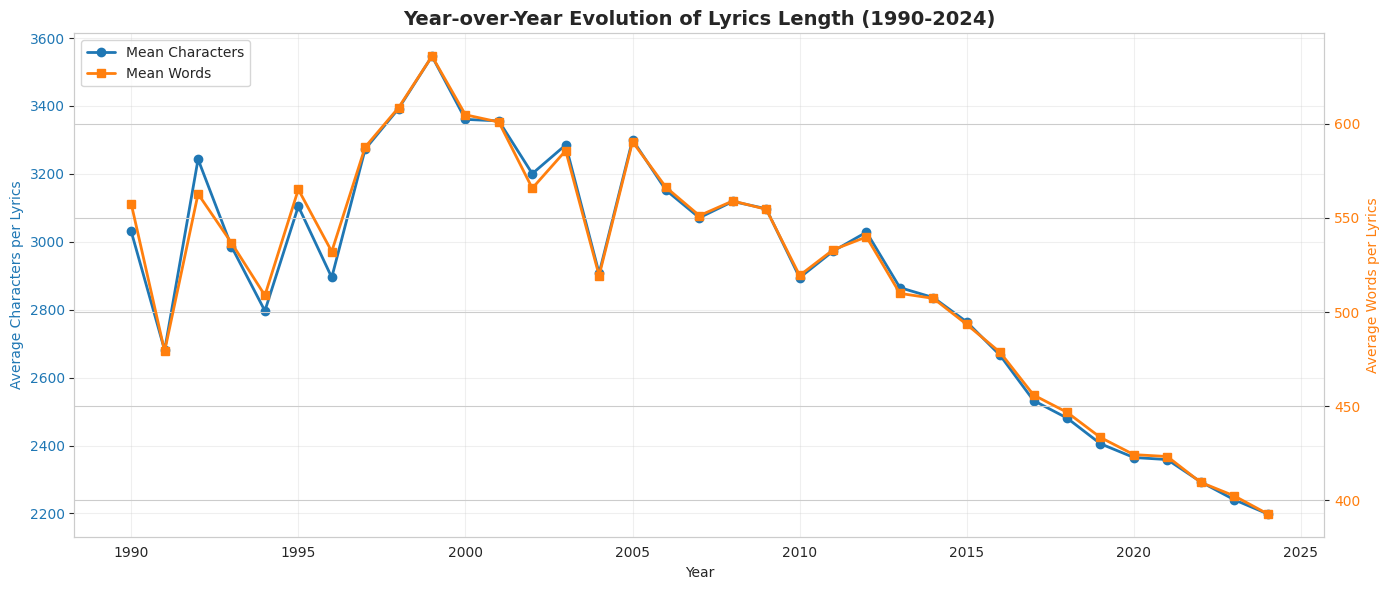

In [50]:
        # Filter to 1990-2024 period and remove rows with missing years
        df_with_year = df[(df['year'].notna()) & (df['year'] >= 1990) & (df['year'] <= 2024)].copy()
        
        if len(df_with_year) > 0:
            # Make sure char_count and word_count exist
            if 'char_count' not in df_with_year.columns:
                df_with_year['char_count'] = df_with_year[text_col].fillna('').astype(str).str.len()
            if 'word_count' not in df_with_year.columns:
                df_with_year['word_count'] = df_with_year[text_col].fillna('').astype(str).str.split().str.len()
            
            # Group by year and calculate statistics
            yearly_stats = df_with_year.groupby('year').agg({
                'char_count': 'mean',
                'word_count': 'mean'
            }).reset_index()
            
            yearly_stats.columns = ['year', 'mean_chars', 'mean_words']
            yearly_stats = yearly_stats.sort_values('year')
            
            print("\n" + "=" * 60)
            print("YEAR-OVER-YEAR STATISTICS (1990-2024)")
            print("=" * 60)
            print(f"Data points: {len(yearly_stats)} years")
            print(f"Documents analyzed: {len(df_with_year):,}")
            print(yearly_stats.to_string(index=False))
            
            # Export yearly statistics
            yearly_stats.to_csv(export_dir / 'R00_yearly_statistics.csv', index=False)
            print(f"\n✓ Yearly statistics exported: export/yearly_statistics.csv")
            
            # Create dual-axis plot
            fig, ax1 = plt.subplots(figsize=(14, 6))
            
            # Plot characters on left axis
            color1 = 'tab:blue'
            ax1.set_xlabel('Year')
            ax1.set_ylabel('Average Characters per Lyrics', color=color1)
            line1 = ax1.plot(yearly_stats['year'], yearly_stats['mean_chars'], 
                            color=color1, marker='o', linewidth=2, markersize=6, label='Mean Characters')
            ax1.tick_params(axis='y', labelcolor=color1)
            ax1.grid(True, alpha=0.3)
            
            # Create right axis for words
            ax2 = ax1.twinx()
            color2 = 'tab:orange'
            ax2.set_ylabel('Average Words per Lyrics', color=color2)
            line2 = ax2.plot(yearly_stats['year'], yearly_stats['mean_words'], 
                            color=color2, marker='s', linewidth=2, markersize=6, label='Mean Words')
            ax2.tick_params(axis='y', labelcolor=color2)
            
            # Title and legend
            plt.title('Year-over-Year Evolution of Lyrics Length (1990-2024)', fontsize=14, fontweight='bold')
            
            # Combine legends from both axes
            lines = line1 + line2
            labels = [l.get_label() for l in lines]
            ax1.legend(lines, labels, loc='upper left', fontsize=10)
            
            fig.tight_layout()
            plt.savefig(images_dir / f'{notebook_prefix}_01b_yearly_evolution.png', dpi=300, bbox_inches='tight')
            print("\n✓ Figure saved: images/01b_yearly_evolution.png")
            plt.show()
        else:
            print("\n⚠ No valid years found in the 1990-2024 period")
            print("The data may contain years outside this range.")

## 5. Word Frequency Analysis


Total unique words: 379,546

Top 30 most frequent words:
  comme: 278,046
  mme: 107,415
  vie: 106,831
  rien: 82,879
  yeah: 73,182
  ya: 68,251
  temps: 55,583
  tte: 52,403
  o: 48,862
  gros: 43,086
  deux: 42,492
  monde: 40,922
  hey: 38,597
  cur: 37,725
  vu: 36,927
  juste: 36,688
  rap: 34,283
  fois: 34,118
  seul: 32,444
  mort: 32,172
  tre: 31,988
  quil: 31,829
  jen: 30,818
  jour: 28,899
  personne: 28,815
  parle: 28,613
  pourquoi: 28,223
  dj: 28,061
  vrai: 27,372
  nan: 27,209

✓ Top 200 words exported: export/top_words.csv
✓ Figure saved: images/02_word_frequency.png


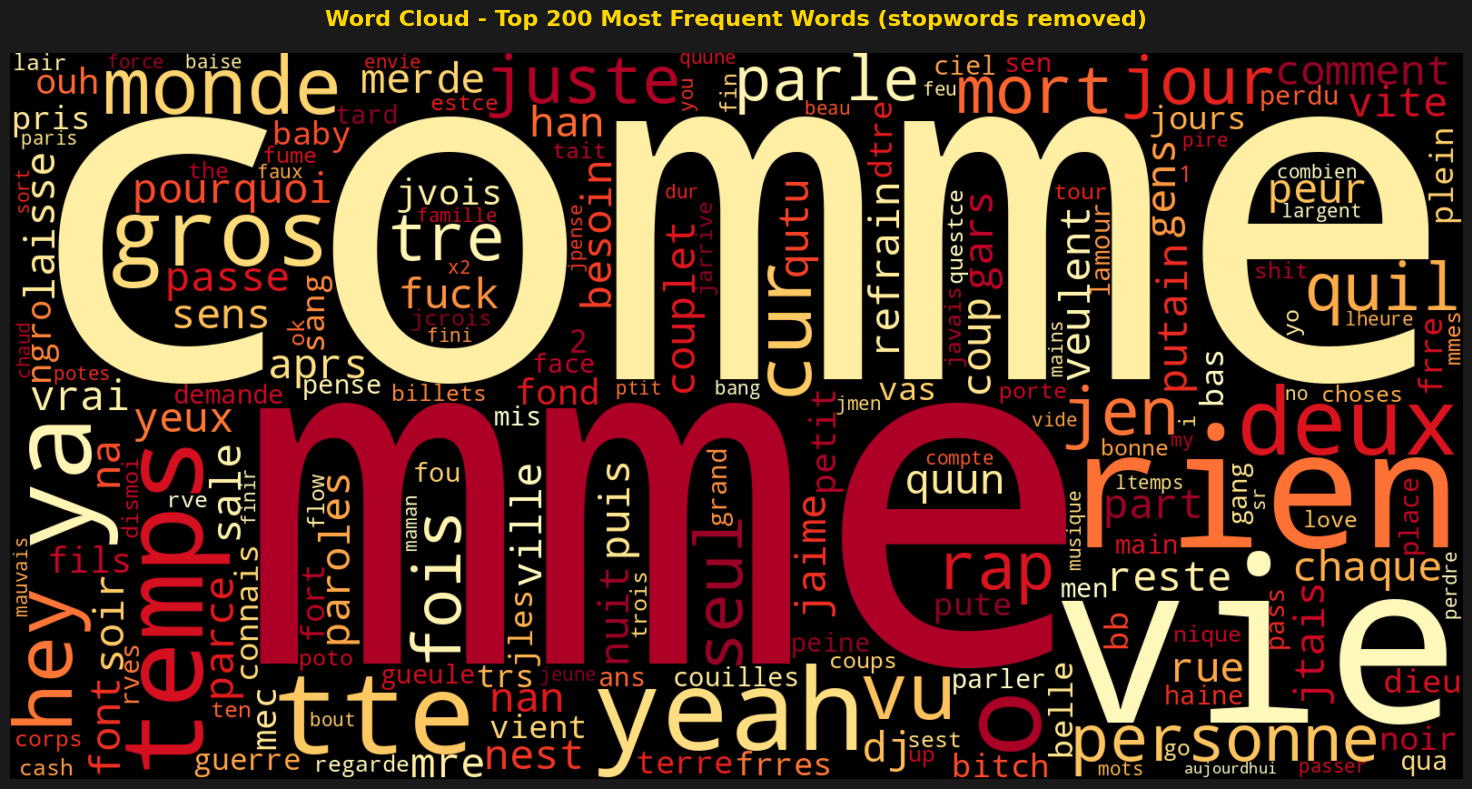

In [52]:
# Define French stopwords - comprehensive list
french_stopwords = {
    # Articles
    'le', 'la', 'les', 'un', 'une', 'des', 'du', 'l', 'au', 'aux', 'da', 'la', 'le',
    # Prépositions
    'à', 'de', 'en', 'par', 'pour', 'sur', 'avec', 'sans', 'sous', 'entre', 'dans',
    'vers', 'pendant', 'jusqu', 'depuis', 'après', 'avant', 'chez', 'selon', 'dès',
    'hors', 'malgré', 'lors', 'contre', 'parmi', 'devant', 'derrière', 'près', 'loin',
    'sauf', 'hormis', 'outre', 'vers', 'nonobstant', 'mors', 'afin', 'environs',
    # Pronoms personnels
    'je', 'tu', 'il', 'elle', 'nous', 'vous', 'ils', 'elles', 'on',
    'me', 'te', 'se', 'moi', 'toi', 'lui', 'eux', 'y', 'en',
    # Pronoms relatifs et démonstratifs
    'qui', 'que', 'quoi', 'dont', 'où', 'ce', 'cet', 'cette', 'ces',
    'celui', 'celle', 'ceux', 'celles', 'ça', 'ca', 'lequel', 'laquelle', 'lesquels', 'lesquelles',
    'ci', 'là', 'ceci', 'cela',
    # Conjonctions
    'et', 'ou', 'mais', 'donc', 'car', 'ni', 'soit', 'or', 'alors', 'lorsque',
    'quand', 'tandis', 'puisque', 'cependant', 'toutefois', 'néanmoins', 'sinon',
    'pourtant', 'bien', 'quoique', 'afin', 'pourvu',
    # Verbes auxiliaires et courants
    'est', 'sont', 'être', 'avoir', 'a', 'ai', 'as', 'avons', 'avez', 'ont',
    'était', 'étaient', 'étais', 'avait', 'avaient', 'sera', 'serait', 'seraient',
    'aura', 'auraient', 'suis', 'es', 'étant', 'ayant', 'ait', 'aient', 'aies',
    # Verbes très courants (faire, dire, prendre, mettre, venir, etc.)
    'faire', 'fais', 'fait', 'faisons', 'faites', 'faisait', 'ferai', 'ferais',
    'dire', 'dis', 'dit', 'disons', 'dites', 'disait', 'dirai', 'dirais',
    'prendre', 'prends', 'prend', 'prenons', 'prenez', 'prenait', 'prendrai',
    'mettre', 'mets', 'met', 'mettons', 'mettez', 'mettait', 'mettrai',
    'venir', 'viens', 'venons', 'veniez', 'venait', 'viendra',
    'aller', 'va', 'vais', 'vont', 'allons', 'allez', 'allait',
    'pouvoir', 'peux', 'peut', 'pouvons', 'pouvez', 'pouvait', 'pourrai',
    'vouloir', 'veux', 'veut', 'voulons', 'voulez', 'voulait', 'voudrai',
    'devoir', 'dois', 'doit', 'devons', 'devez', 'devait', 'devrai',
    'falloir', 'faut', 'fallait', 'faudra',
    'voir', 'vois', 'voit', 'voyons', 'voyez', 'voyait', 'verrai',
    'savoir', 'sais', 'sait', 'savons', 'saviez', 'savait', 'saurai',
    'croire', 'crois', 'croit', 'croyons', 'croyez', 'croyait',
    'vivre', 'vis', 'vit', 'vivons', 'viviez', 'vivait',
    'donner', 'donne', 'donnez', 'donnait', 'donnerai',
    'aller', 'aller', 'viens',
    # Adverbes courants
    'pas', 'ne', 'non', 'oui', 'très', 'plus', 'moins', 'bien', 'mal',
    'jamais', 'toujours', 'souvent', 'rarement', 'ici', 'là', 'maintenant', 'alors',
    'aujourd', 'hier', 'demain', 'encore', 'déjà', 'presque', 'seulement', 'aussi',
    'tant', 'assez', 'guère', 'aucun', 'quelque', 'tout', 'autres', 'autre',
    'trop', 'peu', 'beaucoup', 'tellement', 'vraiment', 'au moins', 'plutôt',
    'bientôt', 'longtemps', 'jamais', 'toujours', 'récemment', 'enfin', 'soudain',
    'particulièrement', 'notamment', 'généralement', 'absolument', 'certainement', 'peut',
    'probablement', 'certainement', 'évidemment', 'justement', 'clairement', 'doucement',
    'fortement', 'directement', 'indirectement', 'rapidement', 'lentement', 'facilement',
    'difficilement', 'naturellement', 'finalement', 'heureusement', 'malheureusement', 'loin',
    'proche', 'environ', 'partout', 'nulle', 'quelque', 'bien', 'mal', 'mieux',
    # Déterminants et articles contractés
    'mon', 'ton', 'son', 'notre', 'votre', 'leur', 'ma', 'ta', 'sa', 'mes', 'tes', 'ses', 'nos', 'vos', 'leurs',
    'quel', 'quelle', 'quels', 'quelles', 'quelques', 'plusieurs', 'beaucoup', 'peu',
    'ce', 'ces', 'cet', 'cette', 'aucun', 'nul', 'aucune', 'nulle', 'certain', 'certains',
    'certaine', 'certaines', 'tout', 'tous', 'toute', 'toutes', 'même', 'mêmes',
    # Particules et petits mots courants
    'c', 'd', 'l', 'n', 't', 's', 'q', 'j', 'z', 'r',
    'qu', 'ca', 'ça', 'là', 'ci', 'pas', 'si', 'ne', 'y', 'en',
    # Exclamations et interjections
    'oh', 'ah', 'eh', 'bah', 'ouf', 'pfut', 'chut', 'hein', 'hum', 'ouais',
    'ouah', 'ouille', 'aïe', 'bon', 'allé', 'bon', 'allez', 'dites', 'dis',
    # Contractions du langage parlé (sans apostrophes) - EXPANDED
    'jai', 'jas', 'jais', 'cest', 'cesque', 'quon', 'quils', 'quelles',
    'jveux', 'jveut', 'jpeux', 'jpeut', 'jfais', 'jfait', 'jsais', 'jsait',
    'jsuis', 'jme', 'jte', 'jti', 'jlui', 'jnous', 'jvous', 'jvais', 'jy',
    'tas', 'tatou', 'tas', 'telqu', 'tetait', 'tais', 'tétais',
    'dun', 'dune', 'dla', 'dquoi', 'dça',
    'ctait', 'cest', 'cque', 'cta', 'cétait', 'cea', 'ceque',
    'ym', 'yn', 'yavait', 'yfait', 'yva',
    'moij', 'moi', 'dja', 'djà', 'tjours', 'tjs', 'tjs',
    'jamis', 'naimais', 'naime', 'naimes', 'nsais', 'nsait',
    'ntais', 'ntai', 'ncest', 'ncesait', 'nceque', 'ncequ',
    'npeux', 'npeut', 'npas', 'nva', 'nvais', 'nvont', 'ny',
    'mfaut', 'mfait', 'mgros', 'mmanque', 'mplait',
    'mouais', 'mouai', 'nvé', 'nvais', 'ckoi', 'cetais',
    'yété', 'yaeu', 'yapas', 'yabien', 'yanul', 'yaeu',
    'pquoi', 'pqu', 'pquoi', 'pce', 'pceque', 'pcequ',
}

# Simple tokenizer and word counter
all_words = []
for text in df[text_col].fillna('').astype(str):
    # Convert to lowercase and split by spaces
    words = text.lower().split()
    # Clean punctuation and filter stopwords
    cleaned_words = [
        re.sub(r'[^a-z0-9]', '', word)
        for word in words
        if word.strip()
    ]
    all_words.extend([w for w in cleaned_words if w and w not in french_stopwords])

# Count frequencies
word_freq = Counter(all_words)
top_n = 30

print(f"\nTotal unique words: {len(word_freq):,}")
print(f"\nTop {top_n} most frequent words:")
for word, freq in word_freq.most_common(top_n):
    print(f"  {word}: {freq:,}")

# Save top words to CSV
top_words_df = pd.DataFrame(
    [(word, freq) for word, freq in word_freq.most_common(200)],
    columns=['word', 'frequency']
)
top_words_df.to_csv(export_dir / 'R00_top_words.csv', index=False)
print(f"\n✓ Top 200 words exported: export/top_words.csv")

# Generate Word Cloud with top 200 words and aggressive logarithmic scaling
top_200_words = dict(word_freq.most_common(200))

# Apply aggressive logarithmic scaling for better word distribution
# Using log(log(freq)) compresses large frequencies more effectively
log_freq = {word: np.log1p(np.log1p(freq)) for word, freq in top_200_words.items()}

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='black',
    colormap='YlOrRd',  # Hip hop aesthetic: gold/orange/red
    max_words=200,
    relative_scaling=0.3,  # Reduced from 0.7 for better balance
    min_font_size=10,
    prefer_horizontal=0.7
).generate_from_frequencies(log_freq)

fig, ax = plt.subplots(figsize=(16, 8), facecolor='#1a1a1a')
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud - Top 200 Most Frequent Words (stopwords removed)', fontsize=16, fontweight='bold', pad=20, color='#FFD700')
plt.tight_layout()
plt.savefig(images_dir / f'{notebook_prefix}_02_word_frequency.png', dpi=300, bbox_inches='tight', facecolor='#1a1a1a')
print("✓ Figure saved: images/02_word_frequency.png")
plt.show()

## 5b. TF-IDF Analysis

Term Frequency-Inverse Document Frequency (TF-IDF) to identify the most important and distinctive words

TF-IDF ANALYSIS

TF-IDF Matrix shape: (85023, 500)
  Documents: 85,023
  Features (unique words): 500

--- Top 30 Most Important Words (by Mean TF-IDF Score) ---
   1. comme                - TF-IDF: 0.0870
   2. meme                 - TF-IDF: 0.0452
   3. vie                  - TF-IDF: 0.0448
   4. yeah                 - TF-IDF: 0.0384
   5. rien                 - TF-IDF: 0.0369
   6. temps                - TF-IDF: 0.0341
   7. etre                 - TF-IDF: 0.0327
   8. aime                 - TF-IDF: 0.0283
   9. monde                - TF-IDF: 0.0282
  10. tete                 - TF-IDF: 0.0280
  11. passe                - TF-IDF: 0.0258
  12. rap                  - TF-IDF: 0.0249
  13. gros                 - TF-IDF: 0.0249
  14. deux                 - TF-IDF: 0.0248
  15. cœur                 - TF-IDF: 0.0234
  16. hey                  - TF-IDF: 0.0230
  17. laisse               - TF-IDF: 0.0226
  18. parle                - TF-IDF: 0.0224
  19. juste                - TF-IDF: 0.0220
  

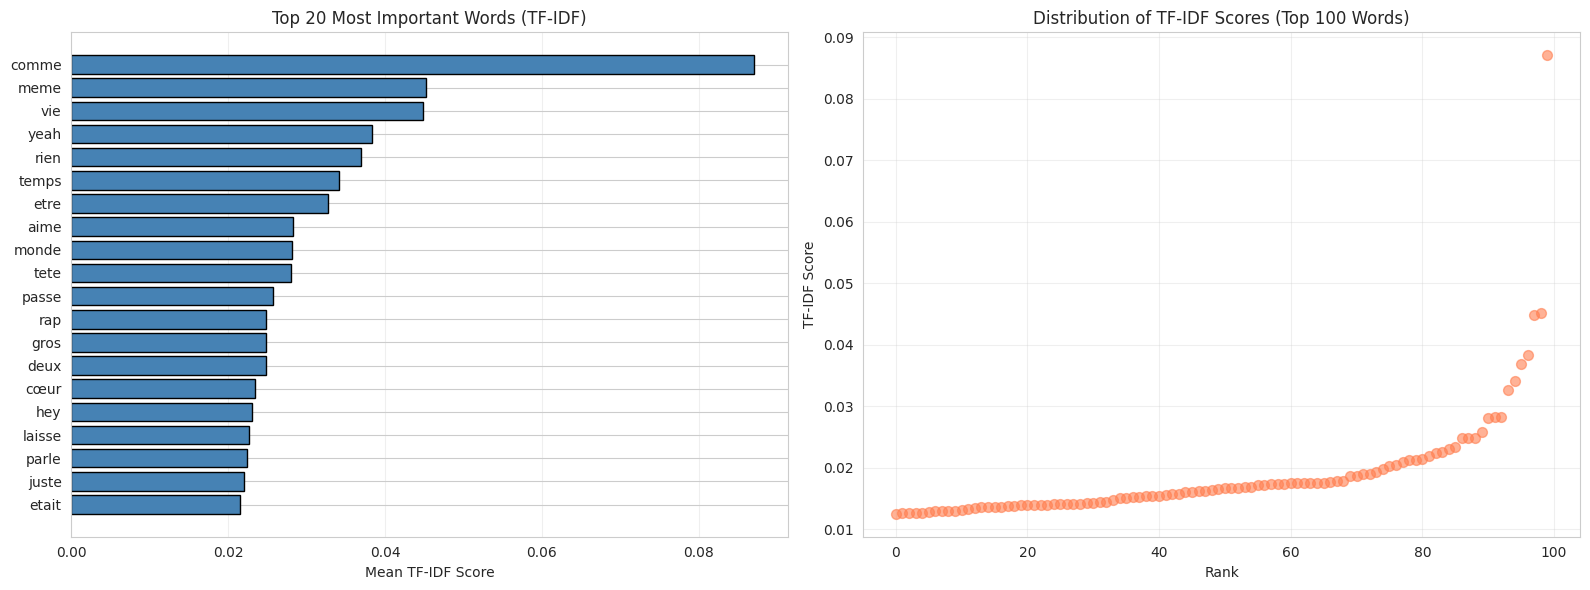


--- Document-Level TF-IDF Analysis ---

Top 5 documents with highest max TF-IDF scores:
  1. Doc ID 46993: 404 BEAT - Feat Twinsmatic
     Most distinctive word: 'bientot' (TF-IDF: 1.0000)
  2. Doc ID 38922: Genius France [Archives] - [GFA] Zürich 2014 – Programme du mardi
     Most distinctive word: '10' (TF-IDF: 1.0000)
  3. Doc ID 53380: Aociz - Shakalaka
     Most distinctive word: 'my' (TF-IDF: 1.0000)
  4. Doc ID 25156: La Fouine - Intro (Planète Trappes 2)
     Most distinctive word: 'yeah' (TF-IDF: 1.0000)
  5. Doc ID 24741: Stupeflip - Keep The Faith
     Most distinctive word: 'nouveau' (TF-IDF: 1.0000)


In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("TF-IDF ANALYSIS")
print("=" * 80)

# Prepare documents (remove NaN values)
documents = df[text_col].fillna('').astype(str).tolist()

# Create TF-IDF vectorizer with French stopwords
tfidf = TfidfVectorizer(
    max_features=500,
    min_df=2,  # Minimum 2 documents
    max_df=0.8,  # Maximum 80% of documents
    ngram_range=(1, 1),  # Unigrams only
    stop_words=list(french_stopwords),
    lowercase=True,
    strip_accents='unicode'
)

# Fit and transform the documents
tfidf_matrix = tfidf.fit_transform(documents)
feature_names = np.array(tfidf.get_feature_names_out())

print(f"\nTF-IDF Matrix shape: {tfidf_matrix.shape}")
print(f"  Documents: {tfidf_matrix.shape[0]:,}")
print(f"  Features (unique words): {tfidf_matrix.shape[1]:,}")

# Calculate mean TF-IDF scores for each word (global importance)
mean_tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
top_indices = np.argsort(mean_tfidf_scores)[-30:][::-1]

print(f"\n--- Top 30 Most Important Words (by Mean TF-IDF Score) ---")
tfidf_results = []
for idx, i in enumerate(top_indices, 1):
    word = feature_names[i]
    score = mean_tfidf_scores[i]
    tfidf_results.append({'rank': idx, 'word': word, 'tfidf_score': score})
    print(f"  {idx:2d}. {word:20s} - TF-IDF: {score:.4f}")

# Export TF-IDF results
tfidf_df = pd.DataFrame(tfidf_results)
tfidf_df.to_csv(export_dir / 'R00_tfidf_analysis.csv', index=False)
print(f"\n✓ TF-IDF analysis exported: export/tfidf_analysis.csv")

# Visualization: Top TF-IDF words
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot: Top 20 TF-IDF words
top_20_indices = np.argsort(mean_tfidf_scores)[-20:][::-1]
top_20_words = feature_names[top_20_indices]
top_20_scores = mean_tfidf_scores[top_20_indices]

axes[0].barh(range(len(top_20_words)), top_20_scores, color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(top_20_words)))
axes[0].set_yticklabels(top_20_words)
axes[0].set_xlabel('Mean TF-IDF Score')
axes[0].set_title('Top 20 Most Important Words (TF-IDF)')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()

# Scatter plot: TF-IDF scores distribution (top 100 words)
top_100_indices = np.argsort(mean_tfidf_scores)[-100:]
top_100_scores = mean_tfidf_scores[top_100_indices]
top_100_words_list = feature_names[top_100_indices]

axes[1].scatter(range(len(top_100_scores)), np.sort(top_100_scores), alpha=0.6, color='coral', s=50)
axes[1].set_xlabel('Rank')
axes[1].set_ylabel('TF-IDF Score')
axes[1].set_title('Distribution of TF-IDF Scores (Top 100 Words)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(images_dir / f'{notebook_prefix}_02c_tfidf_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Figure saved: images/02c_tfidf_analysis.png")
plt.show()

# Per-document analysis: Find most distinctive documents
print(f"\n--- Document-Level TF-IDF Analysis ---")
max_tfidf_per_doc = np.max(tfidf_matrix.toarray(), axis=1)
most_distinctive_doc_idx = np.argsort(max_tfidf_per_doc)[-5:][::-1]

print(f"\nTop 5 documents with highest max TF-IDF scores:")
for rank, doc_idx in enumerate(most_distinctive_doc_idx, 1):
    max_score = max_tfidf_per_doc[doc_idx]
    # Get the word with highest TF-IDF in this document
    top_word_idx = np.argmax(tfidf_matrix[doc_idx].toarray())
    top_word = feature_names[top_word_idx]
    
    if doc_idx < len(df):
        doc_info = df.iloc[doc_idx]
        print(f"  {rank}. Doc ID {doc_info['doc_id']}: {doc_info['artist']} - {doc_info['title']}")
        print(f"     Most distinctive word: '{top_word}' (TF-IDF: {max_score:.4f})")

# Store TF-IDF data for word clouds by era
tfidf_dict = dict(zip(feature_names, mean_tfidf_scores))

## 6. Vocabulary Size and Lexical Diversity

LEXICAL DIVERSITY AND VOCABULARY

Vocabulary:
  Total unique words: 379,546
  Total word tokens: 18,657,621
  Type/Token Ratio (TTR): 0.0203

------------------------------------------------------------
Diversity per Document:
  Mean TTR per document: 0.5075
  Min TTR: 0.0275
  Max TTR: 1.0000
  Median TTR: 0.4978

------------------------------------------------------------
Unique words (appear only once): 173,705
Percentage of vocabulary: 45.77%

------------------------------------------------------------
Word frequency distribution:
  Words appearing 1 time: 173,705
  Words appearing 2-5 times: 100,435
  Words appearing 6-10 times: 30,617
  Words appearing 11+ times: 74,789

✓ Diversity statistics exported: export/lexical_diversity_stats.csv
✓ Figure saved: images/03_lexical_diversity.png


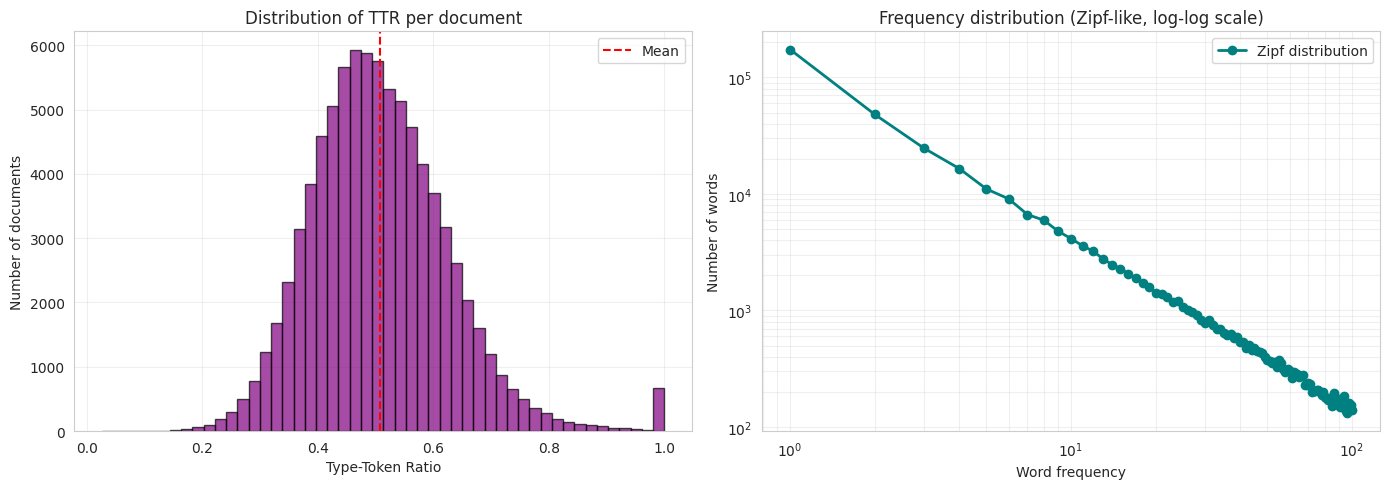

In [ ]:
print("=" * 60)
print("LEXICAL DIVERSITY AND VOCABULARY")
print("=" * 60)

# Total vocabulary size
total_vocab = len(word_freq)
total_words = sum(word_freq.values())

print(f"\nVocabulary:")
print(f"  Total unique words: {total_vocab:,}")
print(f"  Total word tokens: {total_words:,}")
print(f"  Type/Token Ratio (TTR): {total_vocab / total_words:.4f}")

# Diversity per document
print(f"\n" + "-" * 60)
print("Diversity per Document:")

doc_diversity = []
for text in df[text_col].fillna('').astype(str):
    words_in_doc = text.lower().split()
    unique_in_doc = len(set(words_in_doc))
    if len(words_in_doc) > 0:
        ttr = unique_in_doc / len(words_in_doc)
        doc_diversity.append(ttr)

print(f"  Mean TTR per document: {np.mean(doc_diversity):.4f}")
print(f"  Min TTR: {np.min(doc_diversity):.4f}")
print(f"  Max TTR: {np.max(doc_diversity):.4f}")
print(f"  Median TTR: {np.median(doc_diversity):.4f}")

# Rare and frequent words
rare_words = {word: freq for word, freq in word_freq.items() if freq == 1}
print(f"\n" + "-" * 60)
print(f"Unique words (appear only once): {len(rare_words):,}")
print(f"Percentage of vocabulary: {len(rare_words) / total_vocab * 100:.2f}%")

# Frequency distribution
freq_distribution = Counter(word_freq.values())
print(f"\n" + "-" * 60)
print(f"Word frequency distribution:")
print(f"  Words appearing 1 time: {freq_distribution[1]:,}")
print(f"  Words appearing 2-5 times: {sum(c for f, c in freq_distribution.items() if 2 <= f <= 5):,}")
print(f"  Words appearing 6-10 times: {sum(c for f, c in freq_distribution.items() if 6 <= f <= 10):,}")
print(f"  Words appearing 11+ times: {sum(c for f, c in freq_distribution.items() if f >= 11):,}")

# Export diversity statistics
diversity_stats = pd.DataFrame({
    'metric': ['total_vocabulary', 'unique_words', 'global_ttr', 'mean_ttr_doc', 'ttr_min', 'ttr_max', 'ttr_median', 'rare_words', 'pct_rare_words'],
    'value': [total_vocab, total_words, total_vocab / total_words, np.mean(doc_diversity), np.min(doc_diversity), np.max(doc_diversity), np.median(doc_diversity), len(rare_words), len(rare_words) / total_vocab * 100]
})
diversity_stats.to_csv(export_dir / 'R00_lexical_diversity_stats.csv', index=False)
print(f"\n✓ Diversity statistics exported: export/lexical_diversity_stats.csv")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TTR histogram per document
axes[0].hist(doc_diversity, bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[0].axvline(np.mean(doc_diversity), color='red', linestyle='--', label='Mean')
axes[0].set_xlabel('Type-Token Ratio')
axes[0].set_ylabel('Number of documents')
axes[0].set_title('Distribution of TTR per document')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Frequency distribution (log-log scale) - Zipf-like with linear regression
freq_counts = sorted(freq_distribution.items())
if len(freq_counts) > 0:
    freqs, counts = zip(*freq_counts[:min(100, len(freq_counts))])
    freqs_arr = np.array(freqs)
    counts_arr = np.array(counts)
    
    # Plot data points
    axes[1].plot(freqs_arr, counts_arr, color='teal', linewidth=2, marker='o', markersize=6, label='Zipf distribution')
    
    # Fit linear regression on log-log scale
    z = np.polyfit(np.log(freqs_arr), np.log(counts_arr), 1)
    p = np.poly1d(z)
    regression_line = p(np.log(freqs_arr))
    
    # Plot regression line
    axes[1].plot(freqs_arr, np.exp(regression_line), 'r-', linewidth=2.5, label=f'Linear fit (slope={z[0]:.2f})')
    
    axes[1].set_xlabel('Word frequency')
    axes[1].set_ylabel('Number of words')
    axes[1].set_title('Frequency distribution (Zipf-like, log-log scale)')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].grid(True, alpha=0.3, which='both')
    axes[1].legend()

plt.tight_layout()
plt.savefig(images_dir / f'{notebook_prefix}_03_lexical_diversity.png', dpi=300, bbox_inches='tight')
print("✓ Figure saved: images/03_lexical_diversity.png")
plt.show()

## Summary and Export of Global Statistics

In [ ]:
# Create a summary report
summary_report = f"""
================================================================================
EXPLORATORY ANALYSIS REPORT - RAP CORPUS
================================================================================

Analysis date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

1. CORPUS METADATA
-------------------
   - Number of documents: {len(df):,}
   - Number of columns: {df.shape[1]}
   - Analyzed column: {text_col}
   - Memory size: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB

2. LENGTH STATISTICS
---------------------
   Characters per document:
   - Min: {df['char_count'].min():,}
   - Max: {df['char_count'].max():,}
   - Mean: {df['char_count'].mean():,.0f}
   - Median: {df['char_count'].median():,.0f}
   - Std Dev: {df['char_count'].std():,.0f}

   Words per document:
   - Min: {df['word_count'].min():,}
   - Max: {df['word_count'].max():,}
   - Mean: {df['word_count'].mean():,.0f}
   - Median: {df['word_count'].median():,.0f}
   - Std Dev: {df['word_count'].std():,.0f}

   Total words (tokens) in corpus: {sum(word_freq.values()):,}

3. VOCABULARY AND DIVERSITY
-----------------------------
   - Total vocabulary: {len(word_freq):,} unique words
   - Total word tokens: {sum(word_freq.values()):,}
   - Type/Token Ratio (TTR): {len(word_freq) / sum(word_freq.values()):.4f}
   - Mean TTR per document: {np.mean(doc_diversity):.4f}
   - Words appearing only once: {len(rare_words):,} ({len(rare_words) / len(word_freq) * 100:.2f}%)

4. CHARACTER ANALYSIS
----------------------
   - Total characters: {total_chars:,}
   - Letters: {letter_chars:,} ({letter_chars/total_chars*100:.2f}%)
   - Digits: {digit_chars:,} ({digit_chars/total_chars*100:.2f}%)
   - Spaces: {space_chars:,} ({space_chars/total_chars*100:.2f}%)
   - Punctuation: {punctuation_chars:,} ({punctuation_chars/total_chars*100:.2f}%)
   - Other: {other_chars:,} ({other_chars/total_chars*100:.2f}%)

5. TOP MOST FREQUENT WORDS (Top 10)
-------------------------------------
"""

for i, (word, freq) in enumerate(word_freq.most_common(10), 1):
    summary_report += f"   {i:2d}. {word:20s} - {freq:,} occurrences\n"

summary_report += f"""
================================================================================
GENERATED FILES
================================================================================

Images (PNG):
   - 01_text_length.png              : Distribution of text lengths
   - 02_word_frequency.png           : Top 30 most frequent words
   - 03_lexical_diversity.png        : Diversity statistics
   - 04_character_statistics.png     : Character analysis

Data (CSV):
   - top_words.csv                   : Top 100 words with frequencies
   - lexical_diversity_stats.csv     : Lexical diversity metrics
   - character_statistics.csv        : Character distribution
   - summary_report.txt              : This report

================================================================================
END OF REPORT
================================================================================
"""

# Save the report
with open(export_dir / 'summary_report.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)

print(summary_report)
print(f"\n✓ Summary report saved: export/summary_report.txt")